In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
DAI_price_df = pd.read_csv("DAI/DAI_full_dataset.csv")
PAX_price_df = pd.read_csv("PAX/PAX_full_dataset.csv")
USDC_price_df = pd.read_csv("USDC/USDC_full_dataset.csv")
USDT_price_df = pd.read_csv("USDT/USDT_full_dataset.csv")
UST_price_df = pd.read_csv("UST/UST_full_dataset.csv")
df = pd.read_csv("../../data/token_transfers_cleaned.csv")
df['date'] = pd.to_datetime(df['date']).dt.date


In [23]:
DAI_price_df['token_name'] = 'DAI'
PAX_price_df['token_name'] = 'PAX'
USDC_price_df['token_name'] = 'USDC'
USDT_price_df['token_name'] = 'USDT'
UST_price_df['token_name'] = 'UST'

price_df = pd.concat([DAI_price_df, PAX_price_df, USDC_price_df, 
                      USDT_price_df, UST_price_df], ignore_index=True)


df = df.merge(
    price_df[['date', 'token_name', 'close']],
    on=['date', 'token_name'],
    how='left'
)

In [24]:
df.head()

,block_number,transaction_index,from_address,to_address,contract_address,value,timestamp,date,hour,day_of_week,token_name,animal,close
0,14500001,44,0x27cbb0e6885ccb1db2dab7c2314131c94795fbef,0x8426a27add8dca73548f012d92c7f8f4bbd42a3e,0xdac17f958d2ee523a2206206994597c13d831ec7,800.000000,2022-04-01T11:10:21Z,2022-04-01,11,4,USDT,Shrimp\n(<$1K),NaN
1,14500001,62,0x7938b1b2f2d2ec6cde2db46fcb11d824f32eae54,0xffabc91efaf240a48fe2b31d3599925d3504c3df,0xdac17f958d2ee523a2206206994597c13d831ec7,579.000000,2022-04-01T11:10:21Z,2022-04-01,11,4,USDT,Shrimp\n(<$1K),NaN
2,14500001,64,0x4593e0fb8dcc65cd24c7f99ee64da2627e90f998,0x97138e4cb36db0185236c3d74cb39fb51cb3228b,0xdac17f958d2ee523a2206206994597c13d831ec7,15898.000000,2022-04-01T11:10:21Z,2022-04-01,11,4,USDT,Dolphin\n($10K–$100K),NaN
3,14500001,68,0x3cd751e6b0078be393132286c442345e5dc49699,0xf4fc2e12974cc3b4d8192722430c571968025d4f,0xdac17f958d2ee523a2206206994597c13d831ec7,200.929675,2022-04-01T11:10:21Z,2022-04-01,11,4,USDT,Shrimp\n(<$1K),NaN
4,14500003,0,0xffec0067f5a79cff07527f63d83dd5462ccf8ba4,0x5b0e981798f5880c25b54c5de4005f5ec1f3f46a,0xdac17f958d2ee523a2206206994597c13d831ec7,651.675449,2022-04-01T11:10:24Z,2022-04-01,11,4,USDT,Shrimp\n(<$1K),NaN


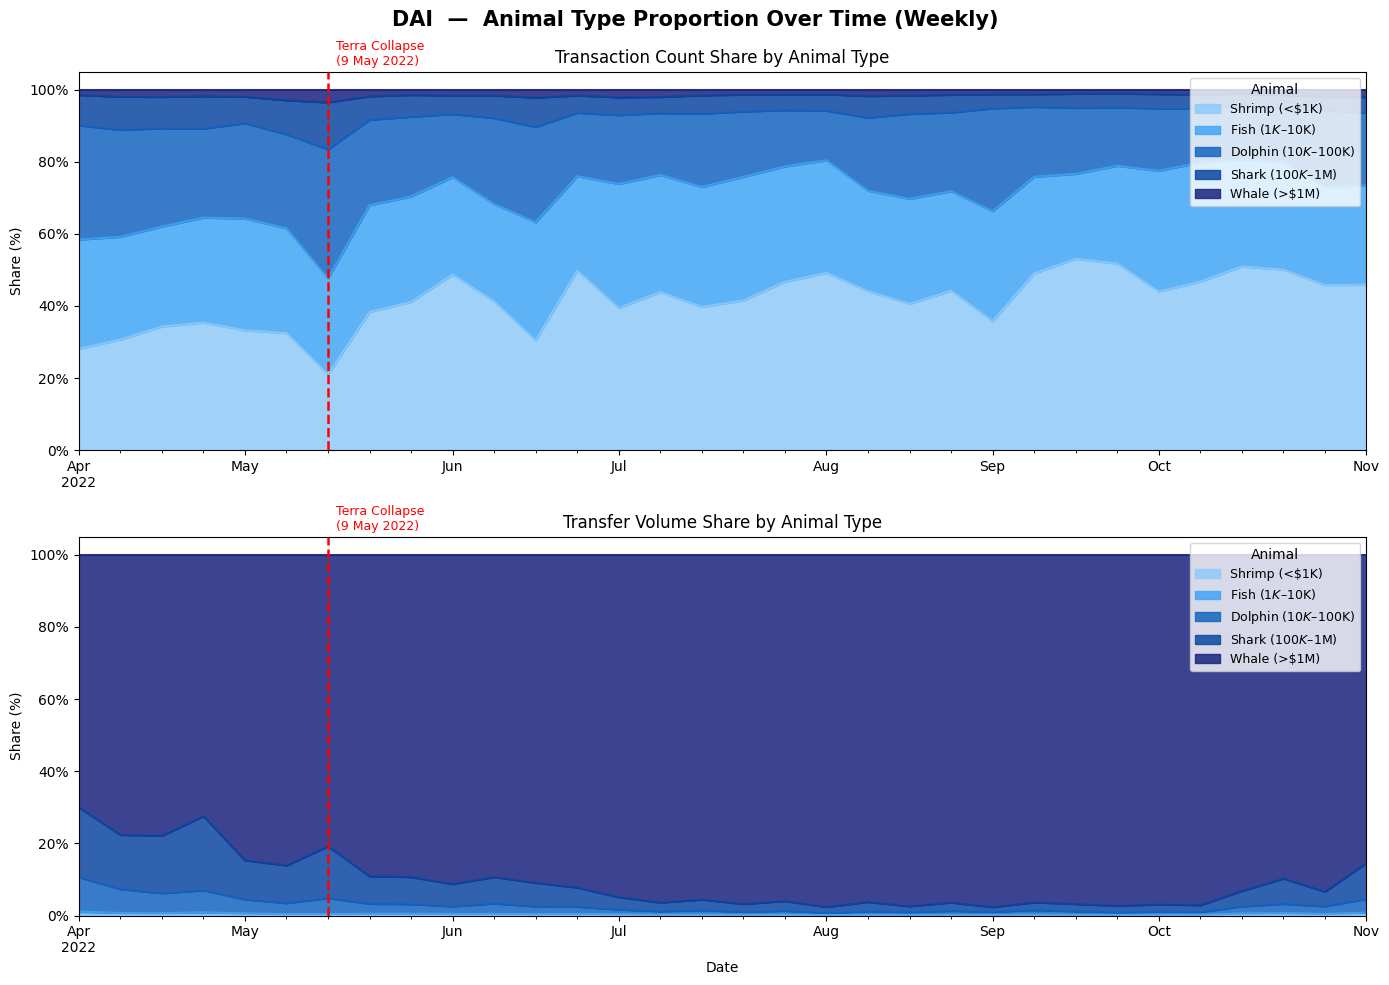

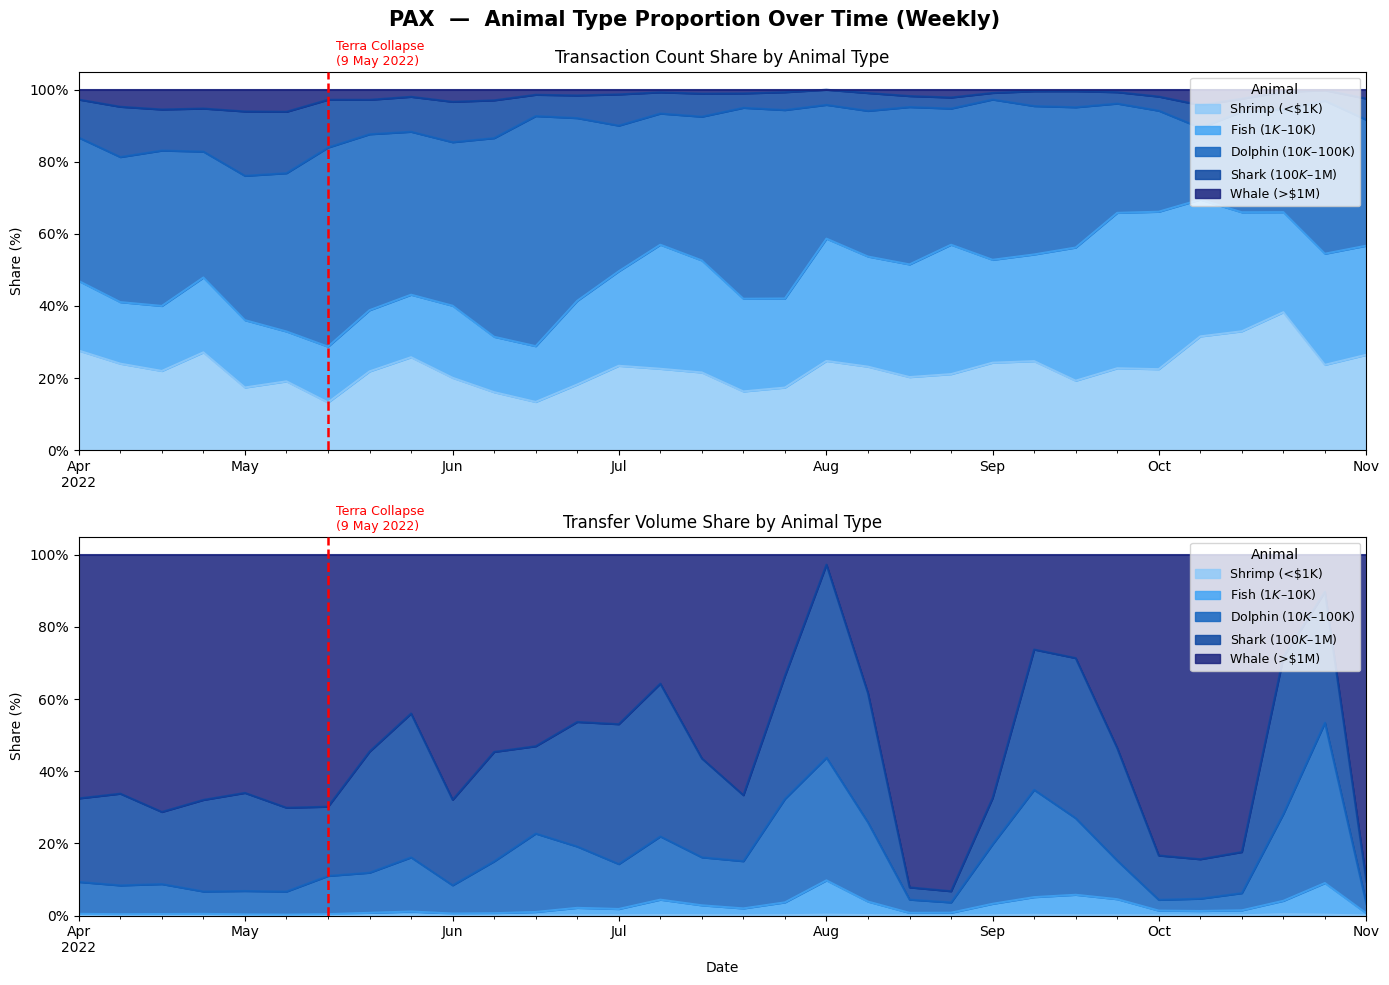

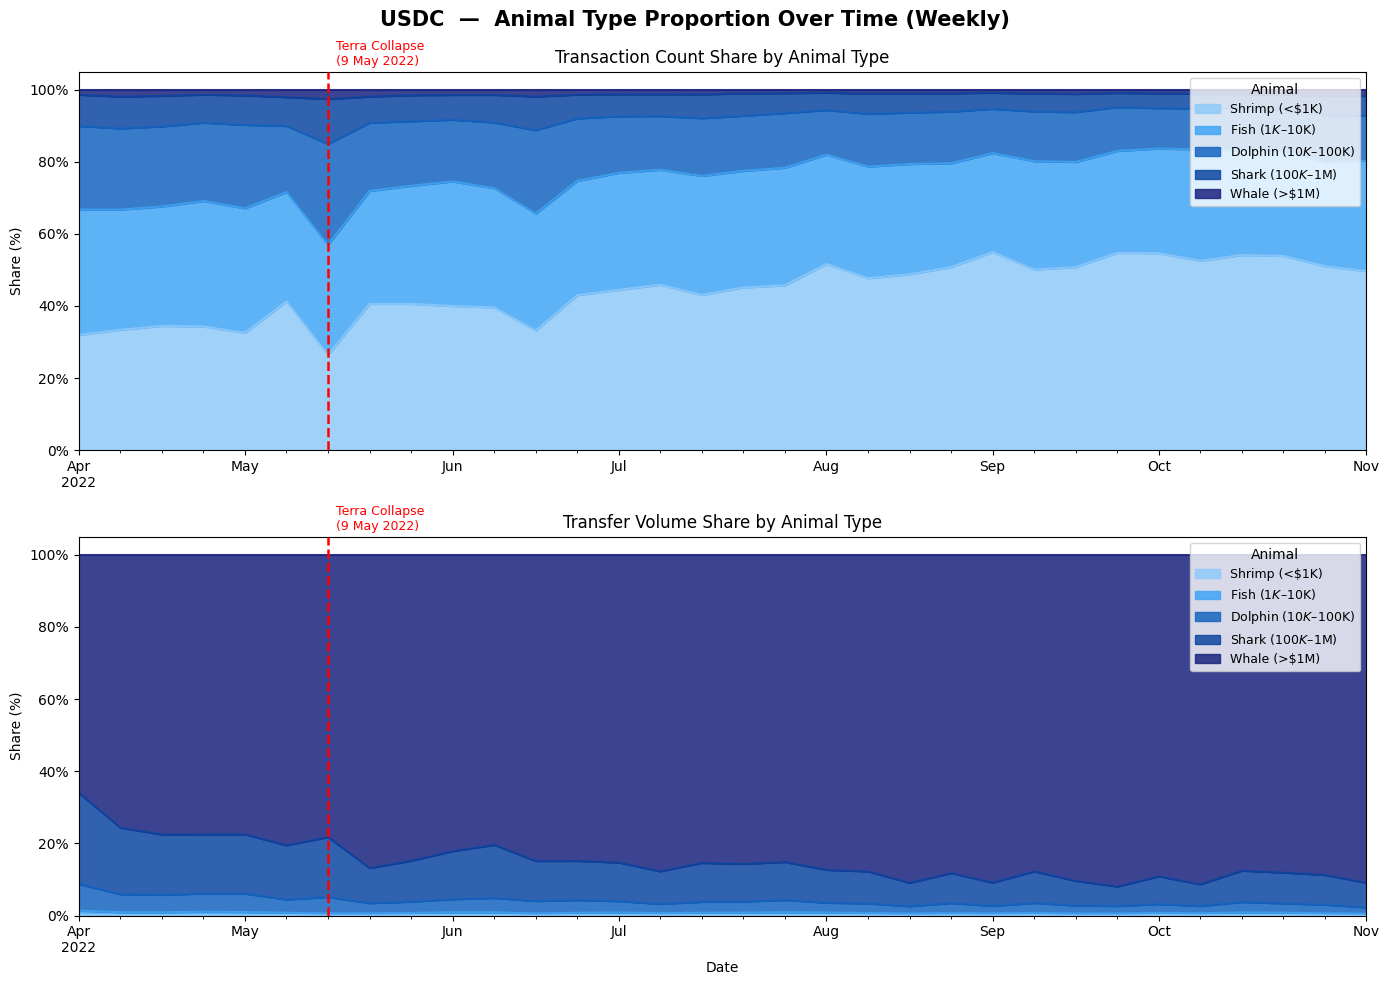

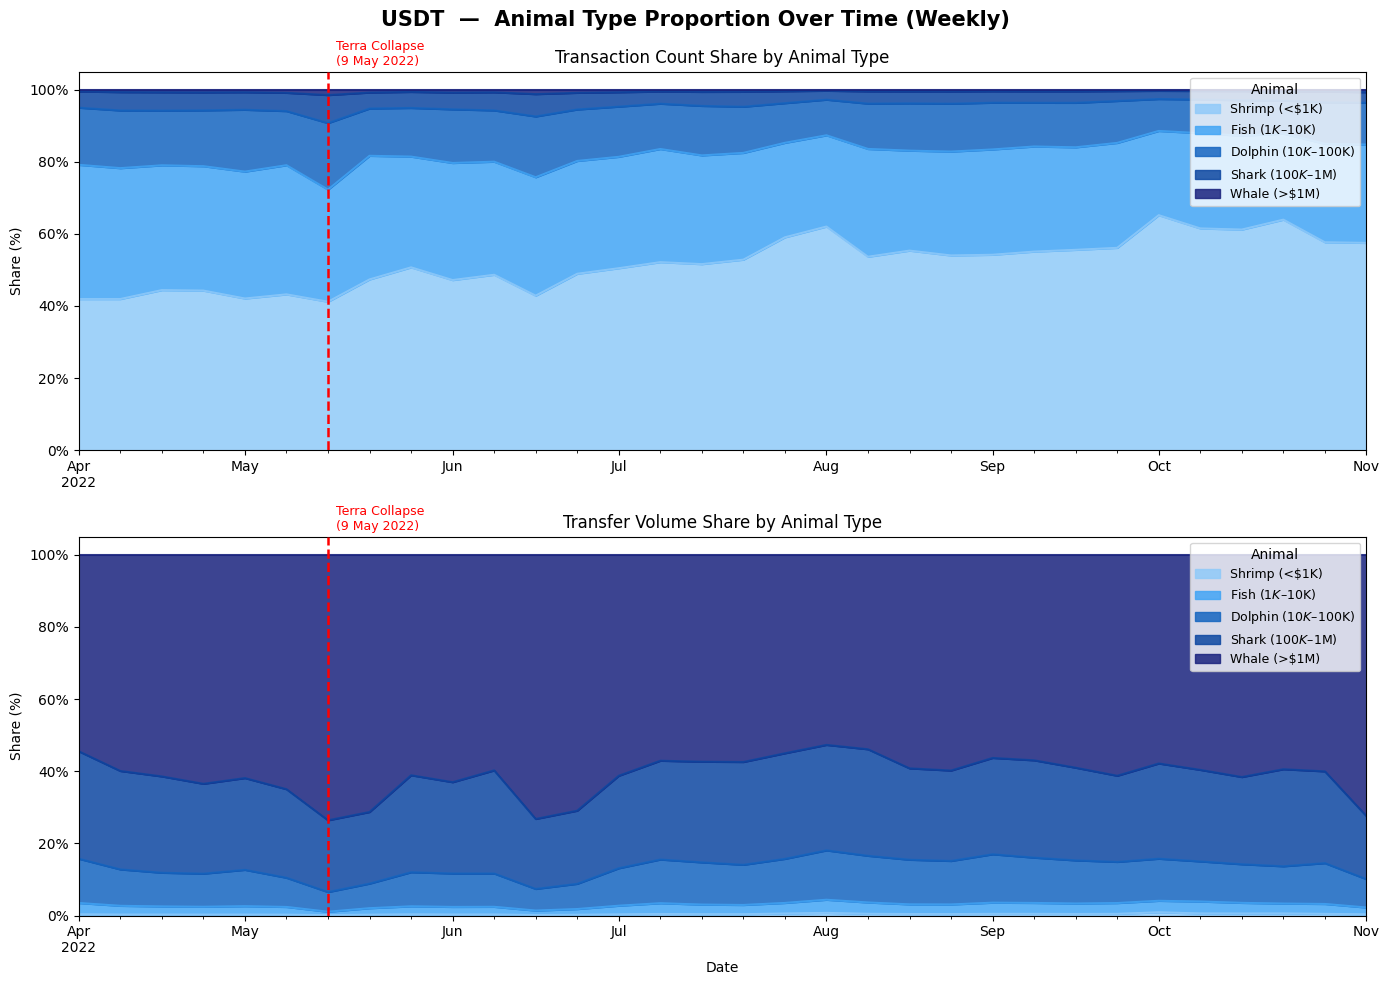

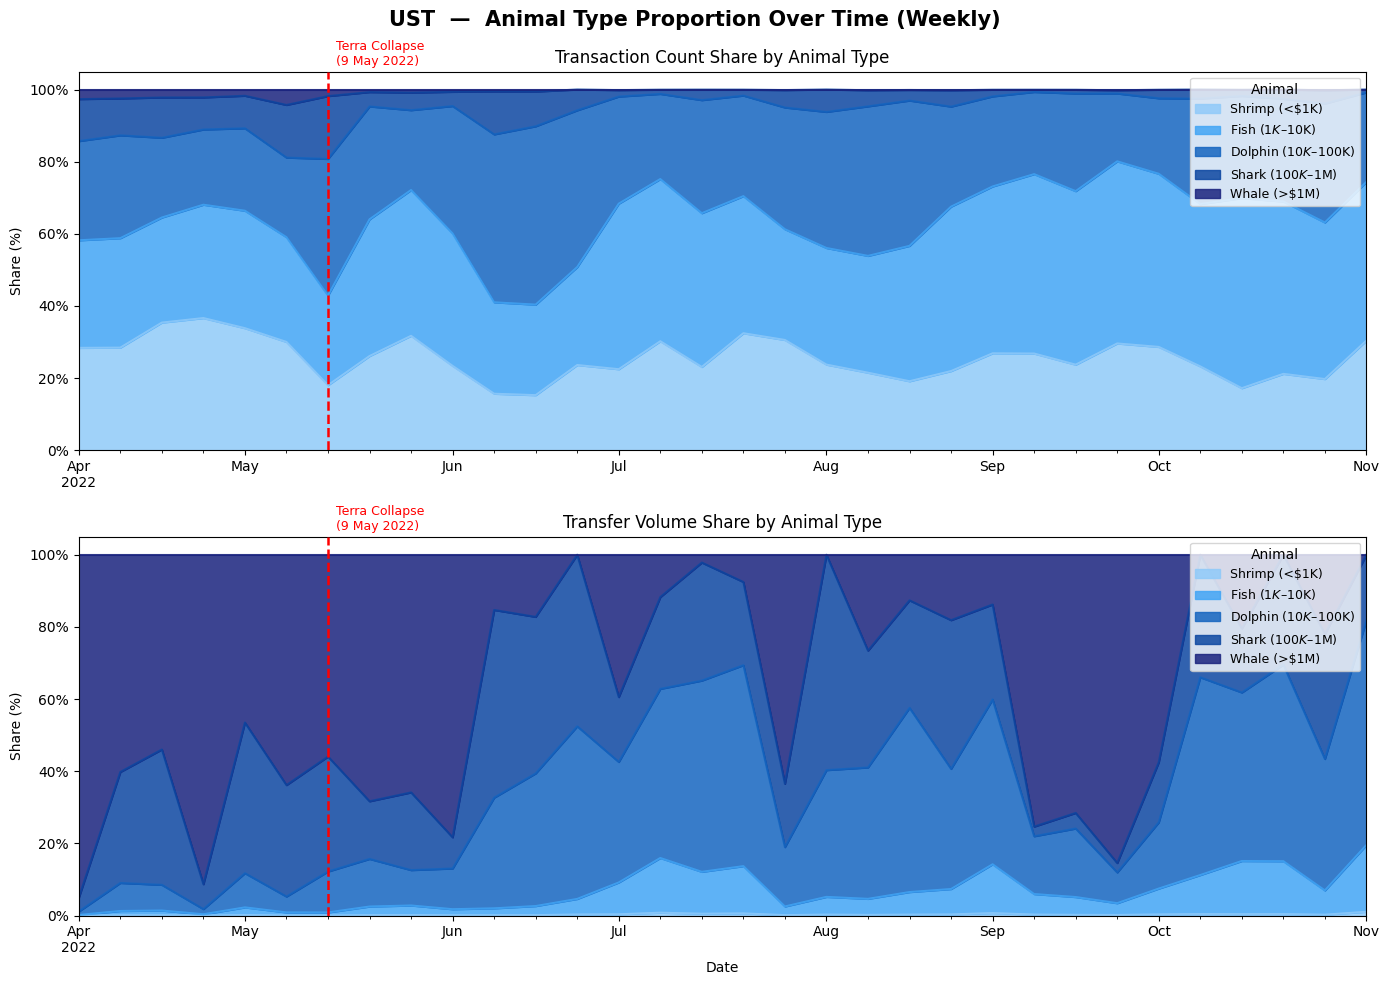

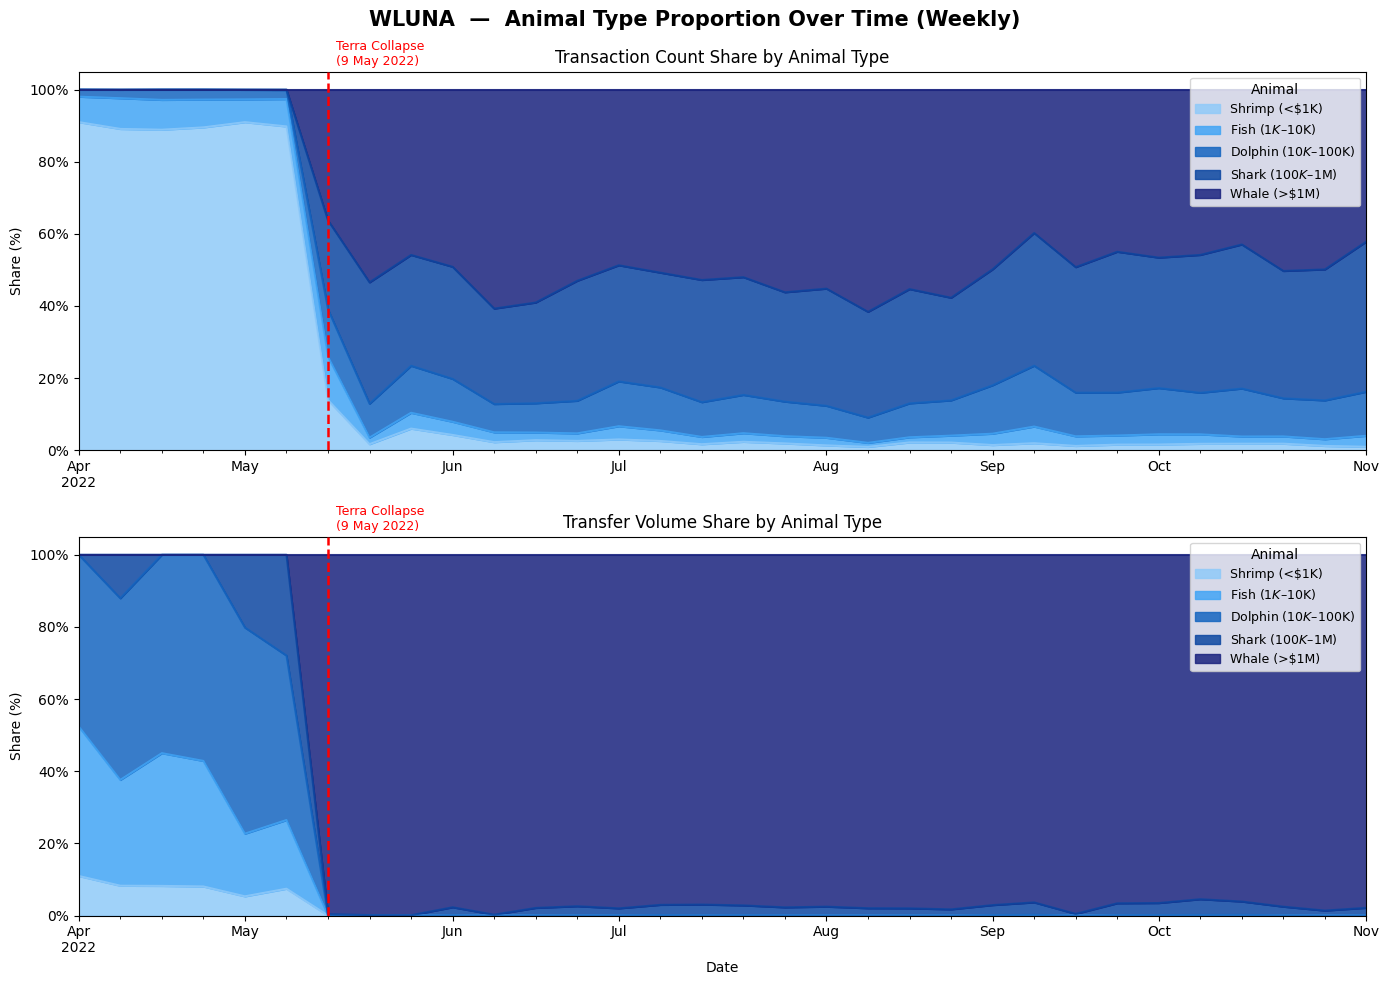

In [ ]:

BINS   = [0, 1_000, 10_000, 100_000, 1_000_000, float('inf')]
LABELS = ['Shrimp\n(<$1K)', 'Fish\n($1K–$10K)', 'Dolphin\n($10K–$100K)',
          'Shark\n($100K–$1M)', 'Whale\n(>$1M)']
COLORS = ['#90caf9', '#42a5f5', '#1565c0', '#0d47a1', '#1a237e']

df['animal'] = pd.cut(df['value'], bins=BINS, labels=LABELS, right=False)

TERRA_COLLAPSE = pd.Timestamp('2022-05-09')

# ── One figure per coin ────────────────────────────────────────────────────
for coin, cdf in df.groupby('token_name'):

    weekly_count = (
        cdf.groupby([pd.Grouper(key='date', freq='W'), 'animal'])
           .size().unstack(fill_value=0)
           .reindex(columns=LABELS, fill_value=0)
    )
    weekly_count_pct = weekly_count.div(weekly_count.sum(axis=1), axis=0) * 100

    weekly_vol = (
        cdf.groupby([pd.Grouper(key='date', freq='W'), 'animal'])['value']
           .sum().unstack(fill_value=0)
           .reindex(columns=LABELS, fill_value=0)
    )
    weekly_vol_pct = weekly_vol.div(weekly_vol.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f'{coin}  —  Animal Type Proportion Over Time (Weekly)',
                 fontsize=15, fontweight='bold')

    for ax, data, title in [
        (axes[0], weekly_count_pct, 'Transaction Count Share by Animal Type'),
        (axes[1], weekly_vol_pct,   'Transfer Volume Share by Animal Type'),
    ]:
        data.plot(kind='area', stacked=True, ax=ax, color=COLORS, alpha=0.85)
        ax.set_ylabel('Share (%)')
        ax.set_title(title, fontsize=12)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_xlabel('')

        # Fix legend labels (strip newlines for readability in legend)
        handles, _ = ax.get_legend_handles_labels()
        ax.legend(handles, [l.replace('\n', ' ') for l in LABELS],
                  loc='upper right', title='Animal', fontsize=9)

        # Terra Collapse vertical line
        ax.axvline(TERRA_COLLAPSE, color='red', linestyle='--', linewidth=1.8, zorder=5)
        ax.text(TERRA_COLLAPSE, 1.01, '  Terra Collapse\n  (9 May 2022)',
                transform=ax.get_xaxis_transform(),
                color='red', fontsize=9, va='bottom', ha='left')

    axes[1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()